In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fire_area_matrix = np.load('/Users/isaaclee/Wildfire_Research/root_recursive_validation_wildfire_results/depth_4_epochs_10000_schedule_VE_sigma_2/root_fire_area_matrix.npz')
fire_area_growth_matrix = fire_area_matrix['arr_0']

print(fire_area_growth_matrix.shape)

(11, 100, 3)


In [3]:
area = np.sum(fire_area_growth_matrix[:, :, 2], axis=0)
#print(area)
print(np.mean(area))
print(np.std(area))
pred_area = np.mean(area)

condition_matrix = np.load("/Users/isaaclee/Wildfire_Research/validation_case_data_and_preparation/root_validation_case_data.npy")
real_fire_area_growth = condition_matrix[:, 2]
#print(real_fire_area_growth)

target_area = np.sum(real_fire_area_growth)
print(target_area)

20450.821744369754
8531.056950348402
7138.102266974867


In [4]:
pred_fire_area = fire_area_growth_matrix.copy()
mean_pred_fire_area = np.zeros(shape=(11))
std_at_timestep = np.zeros(shape=(11))
real_fire_area = real_fire_area_growth.copy()

for i in range(1,11):
    pred_fire_area[i, :, 2] = fire_area_growth_matrix[i, :, 2] + pred_fire_area[i-1, :, 2]
    real_fire_area[i] = real_fire_area_growth[i] + real_fire_area[i-1]

for i in range(0,11):
    mean_pred_fire_area[i] = np.mean(pred_fire_area[i, :, 2])
    std_at_timestep[i] = np.std(pred_fire_area[i, :, 2])

zeros = np.zeros((1, 100, 3))
pred_fire_area = np.concatenate((zeros, pred_fire_area), axis=0)
pred_fire_area = pred_fire_area[:, :, 2]
mean_pred_fire_area = np.insert(mean_pred_fire_area, 0, 0)
std_at_timestep = np.insert(std_at_timestep, 0, 0)
real_fire_area = np.insert(real_fire_area, 0, 0)

print(f"Shape of pred_fire_area matrix: {pred_fire_area.shape}")
print(f"Real fire area {real_fire_area}")
print(f"Mean predicted fire area {mean_pred_fire_area}")
print(f"Standard deviations {std_at_timestep}")

area_plus_1std  = mean_pred_fire_area + std_at_timestep
area_minus_1std = mean_pred_fire_area - std_at_timestep

Shape of pred_fire_area matrix: (12, 100)
Real fire area [   0.           38.91909758  364.63487856  803.24693071 1120.00514161
 1537.45879547 1897.30600727 2275.84056354 2863.79693062 3881.25333892
 5567.12980414 7138.10226697]
Mean predicted fire area [    0.           145.22537281   453.58958176   906.08419212
  1681.75020936  2855.1116763   4639.08015406  6755.76719866
  9180.99097047 12030.68552208 15394.5311252  20450.82174437]
Standard deviations [   0.          110.24850275  372.28988774  788.85103263 1404.74915753
 1990.04513656 2529.71987204 2769.78986848 3165.13123838 3935.54317249
 6015.60092325 8531.05695035]


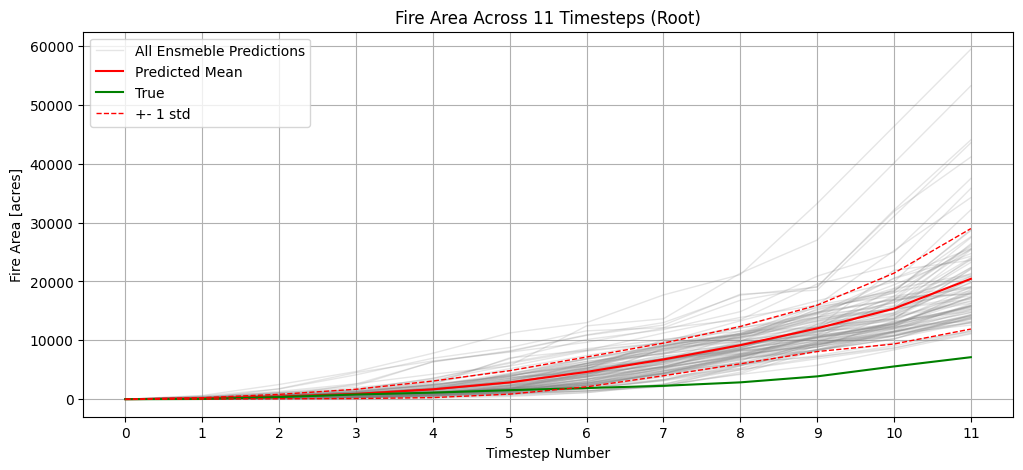

In [5]:
plt.figure(figsize=(12,5))
plt.title('Fire Area Across 11 Timesteps (Root)')
plt.xlabel('Timestep Number')
plt.xticks(range(0, 12))
plt.ylabel('Fire Area [acres]')
plt.grid(True)
for i in range(0,100):
    if i == 0:
        plt.plot(pred_fire_area[:, i], color='gray', alpha=0.2, linewidth=1, label='All Ensmeble Predictions')
    else:
        plt.plot(pred_fire_area[:, i], alpha=0.2, linewidth=1, color='gray')
plt.plot(mean_pred_fire_area, color='red', label='Predicted Mean')
plt.plot(real_fire_area, color='green', label='True')
plt.plot(area_plus_1std, color='red', alpha=1, linewidth=1, linestyle='dashed', label='+- 1 std')
plt.plot(area_minus_1std, color='red', alpha=1, linewidth=1, linestyle='dashed')
plt.legend()
plt.show()

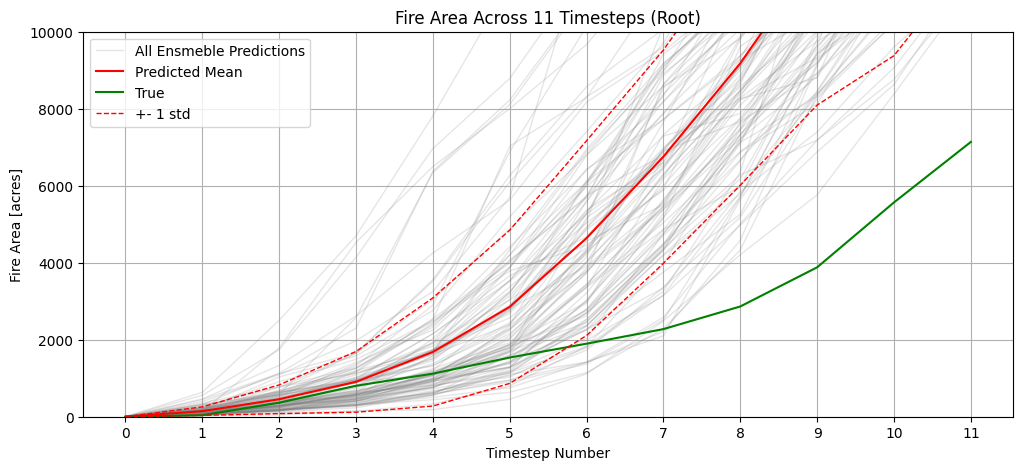

In [6]:
plt.figure(figsize=(12,5))
plt.title('Fire Area Across 11 Timesteps (Root)')
plt.xlabel('Timestep Number')
plt.xticks(range(0, 12))
plt.ylabel('Fire Area [acres]')
plt.ylim(top=10000)
plt.grid(True)
for i in range(0,100):
    if i == 0:
        plt.plot(pred_fire_area[:, i], color='gray', alpha=0.2, linewidth=1, label='All Ensmeble Predictions')
    else:
        plt.plot(pred_fire_area[:, i], alpha=0.2, linewidth=1, color='gray')
plt.plot(mean_pred_fire_area, color='red', label='Predicted Mean')
plt.plot(real_fire_area, color='green', label='True')
plt.plot(area_plus_1std, color='red', alpha=1, linewidth=1, linestyle='dashed', label='+- 1 std')
plt.plot(area_minus_1std, color='red', alpha=1, linewidth=1, linestyle='dashed')
plt.legend()
plt.show()